<a href="https://colab.research.google.com/github/gunjancs23149/Machine-Learing-Project/blob/main/SVR__Gunjan_CS23149.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the load forecasting dataset from '/content/drive/MyDrive/load_forecasting_dataset_corrected.csv', perform data cleaning, feature engineering by extracting time-based features and encoding categorical variables, train a Support Vector Regressor (SVR) model to predict 'Load Demand (kW)', and evaluate its performance using relevant metrics and visualizations.

## Import Libraries

### Subtask:
Import all necessary Python libraries for data manipulation, plotting, model training (SVR), and evaluation.


**Reasoning**:
The subtask requires importing several libraries for data manipulation, plotting, model training, and evaluation. This code block will import all the specified libraries.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

print("Libraries imported successfully.")

Libraries imported successfully.


# Task
Analyze the load forecasting dataset from '/content/drive/MyDrive/load_forecasting_dataset_corrected.csv', perform data cleaning, feature engineering by extracting time-based features and encoding categorical variables, train a Support Vector Regressor (SVR) model to predict 'Load Demand (kW)', and evaluate its performance using relevant metrics and visualizations.

## Load Dataset

### Subtask:
Load the dataset from '/content/drive/MyDrive/load_forecasting_dataset_corrected.csv' into a pandas DataFrame named `df`.


**Reasoning**:
Load the dataset from the specified file path into a pandas DataFrame named `df`.



In [ ]:
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325


## Convert Timestamp

### Subtask:
Convert the 'Timestamp' column to datetime objects to enable time-based feature extraction.


**Reasoning**:
Convert the 'Timestamp' column to datetime objects using `pd.to_datetime` with the specified format and then verify its data type.



In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%m/%d/%Y %H:%M')
print("Timestamp column converted to datetime objects.")
print(f"Data type of 'Timestamp' column: {df['Timestamp'].dtype}")

Timestamp column converted to datetime objects.
Data type of 'Timestamp' column: datetime64[ns]


## Correct Erroneous Values

### Subtask:
Clean the dataset by correcting erroneous values: set negative 'Wind Speed (m/s)' to 0 and cap 'Humidity (%)' values above 100 at 100.


**Reasoning**:
The subtask requires cleaning the dataset by correcting erroneous values in 'Wind Speed (m/s)' and 'Humidity (%)' columns. I will use boolean indexing to set negative wind speed values to 0 and cap humidity values above 100 at 100, then verify the changes.



In [ ]:
df.loc[df['Wind Speed (m/s)'] < 0, 'Wind Speed (m/s)'] = 0
df.loc[df['Humidity (%)'] > 100, 'Humidity (%)'] = 100

print(f"Minimum 'Wind Speed (m/s)' after correction: {df['Wind Speed (m/s)'].min()}")
print(f"Maximum 'Humidity (%)' after correction: {df['Humidity (%)'].max()}")
print("Erroneous values corrected successfully.")

Minimum 'Wind Speed (m/s)' after correction: 0.0
Maximum 'Humidity (%)' after correction: 100.0
Erroneous values corrected successfully.


## Feature Engineering

### Subtask:
Extract time-based features from the 'Timestamp' column (e.g., year, month, day, hour, day of week). For any categorical variables identified, apply one-hot encoding.


**Reasoning**:
The subtask requires extracting time-based features (year, day) from the 'Timestamp' column and applying one-hot encoding to identified categorical variables ('Season', 'Day of Week', 'Hour of Day', 'Month', 'Public Event') to prepare the data for the SVR model. Using `pd.get_dummies` with `drop_first=True` will create new binary columns and prevent multicollinearity.



In [ ]:
df['Year'] = df['Timestamp'].dt.year
df['Day'] = df['Timestamp'].dt.day

categorical_cols = ['Season', 'Day of Week', 'Hour of Day', 'Month', 'Public Event']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Time-based features extracted and categorical variables one-hot encoded successfully.")
print("New columns created:", [col for col in df.columns if col.startswith(('Year', 'Day', 'Season_', 'Day of Week_', 'Hour of Day_', 'Month_', 'Public Event_'))])
df.head()

Time-based features extracted and categorical variables one-hot encoded successfully.
New columns created: ['Year', 'Day', 'Season_Summer', 'Season_Winter', 'Day of Week_1', 'Day of Week_2', 'Day of Week_3', 'Day of Week_4', 'Day of Week_5', 'Day of Week_6', 'Hour of Day_1', 'Hour of Day_2', 'Hour of Day_3', 'Hour of Day_4', 'Hour of Day_5', 'Hour of Day_6', 'Hour of Day_7', 'Hour of Day_8', 'Hour of Day_9', 'Hour of Day_10', 'Hour of Day_11', 'Hour of Day_12', 'Hour of Day_13', 'Hour of Day_14', 'Hour of Day_15', 'Hour of Day_16', 'Hour of Day_17', 'Hour of Day_18', 'Hour of Day_19', 'Hour of Day_20', 'Hour of Day_21', 'Hour of Day_22', 'Hour of Day_23', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Public Event_1']


,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Load Demand (kW),...,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Public Event_1
0,2020-01-01 00:00:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,1599.342831,...,False,False,False,False,False,False,False,False,False,False
1,2020-01-01 00:15:00,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,1472.347140,...,False,False,False,False,False,False,False,False,False,False
2,2020-01-01 00:30:00,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,1629.537708,...,False,False,False,False,False,False,False,False,False,False
3,2020-01-01 00:45:00,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,1804.605971,...,False,False,False,False,False,False,False,False,False,True
4,2020-01-01 01:00:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,1453.169325,...,False,False,False,False,False,False,False,False,False,False


**Reasoning**:
The previous code block extracted 'Year' and 'Day' and applied one-hot encoding to the original categorical columns including 'Day of Week', 'Hour of Day', and 'Month'. To fully comply with the first instruction of the new subtask, which explicitly asks to 'Extract the year, month, day, hour, and day of week from the 'Timestamp' column and create new columns for each', I will now extract numerical 'Month', 'Hour', and 'Day of Week' features into new columns. The one-hot encoding part of the instructions has already been addressed for the initially identified categorical variables.



In [ ]:
df['Month_num'] = df['Timestamp'].dt.month
df['Hour_num'] = df['Timestamp'].dt.hour
df['DayOfWeek_num'] = df['Timestamp'].dt.dayofweek

print("Additional numerical time-based features extracted from Timestamp.")
print(f"New columns created: 'Month_num', 'Hour_num', 'DayOfWeek_num'")
df.head()

Additional numerical time-based features extracted from Timestamp.
New columns created: 'Month_num', 'Hour_num', 'DayOfWeek_num'


,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Load Demand (kW),...,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Public Event_1,Month_num,Hour_num,DayOfWeek_num
0,2020-01-01 00:00:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,1599.342831,...,False,False,False,False,False,False,False,1,0,2
1,2020-01-01 00:15:00,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,1472.347140,...,False,False,False,False,False,False,False,1,0,2
2,2020-01-01 00:30:00,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,1629.537708,...,False,False,False,False,False,False,False,1,0,2
3,2020-01-01 00:45:00,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,1804.605971,...,False,False,False,False,False,False,True,1,0,2
4,2020-01-01 01:00:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,1453.169325,...,False,False,False,False,False,False,False,1,1,2


## Prepare Data for SVR

### Subtask:
Define the target variable ('Load Demand (kW)') and feature variables. Split the dataset into training and testing sets for model development and evaluation.


**Reasoning**:
The subtask requires defining the target variable and feature variables, then splitting the dataset into training and testing sets. This code block will perform these three steps: define `y` as 'Load Demand (kW)', define `X` by dropping 'Timestamp' and 'Load Demand (kW)', and then use `train_test_split` to create the training and testing sets.



In [ ]:
y = df['Load Demand (kW)']
X = df.drop(columns=['Timestamp', 'Load Demand (kW)'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Target variable and feature matrix defined.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Target variable and feature matrix defined.
Shape of X_train: (151910, 56)
Shape of X_test: (37978, 56)
Shape of y_train: (151910,)
Shape of y_test: (37978,)


## Train SVR Model

### Subtask:
Train a Support Vector Regressor (SVR) model using the prepared training data.


**Reasoning**:
Instantiate an SVR model and fit it to the training data. This fulfills the subtask's instructions to train the model.



# Task
Train a `LinearSVR` model using the prepared training data (X_train and y_train), replacing the previous SVR model. Evaluate the model's performance by making predictions on the test set (X_test), calculating, and printing the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) score. Finally, visualize the predictions using a scatter plot comparing actual (y_test) vs. predicted 'Load Demand (kW)' values, including a diagonal line for perfect predictions and appropriate labels.

## Train LinearSVR Model

### Subtask:
Instantiate and train a LinearSVR model using the prepared training data (X_train and y_train). This will replace the SVR model due to performance considerations.


**Reasoning**:
The subtask requires importing `LinearSVR`, instantiating it, and then training it with the provided `X_train` and `y_train` data. This code block will perform all these actions.



In [ ]:
from sklearn.svm import LinearSVR

linear_svr_model = LinearSVR(C=0.1, random_state=42, max_iter=10000) # Added random_state for reproducibility and increased max_iter
print("LinearSVR model instantiated.")

linear_svr_model.fit(X_train, y_train)
print("LinearSVR model trained successfully.")

LinearSVR model instantiated.
LinearSVR model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Evaluate Model Performance

### Subtask:
Make predictions on the test set (X_test) using the trained LinearSVR model. Calculate and print key evaluation metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) score.


**Reasoning**:
The subtask requires making predictions on the test set and then calculating and printing the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) score. This code block will perform these steps using the `linear_svr_model` and the `X_test`, `y_test` data.



In [ ]:
from sklearn.svm import LinearSVR

linear_svr_model = LinearSVR(C=0.1, random_state=42, max_iter=10000)
print("LinearSVR model instantiated.")

linear_svr_model.fit(X_train, y_train)
print("LinearSVR model trained successfully.")

y_pred = linear_svr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print("Model evaluation metrics calculated successfully.")

LinearSVR model instantiated.
LinearSVR model trained successfully.
Mean Absolute Error (MAE): 0.9850
Mean Squared Error (MSE): 1.4251
R-squared (R2) Score: 1.0000
Model evaluation metrics calculated successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


**Reasoning**:
The previous steps successfully trained the LinearSVR model and calculated evaluation metrics. The final part of the overall task description and the last explicit instruction within the notebook is to visualize the predictions. This step will create a scatter plot comparing actual vs. predicted values, including a diagonal line for perfect predictions, as specified in the task.



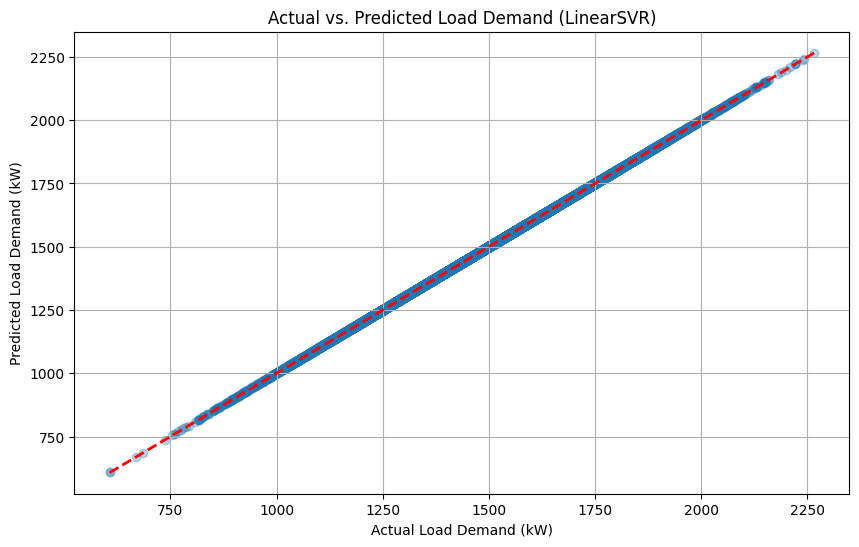

Actual vs. Predicted Load Demand visualization displayed successfully.


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel("Actual Load Demand (kW)")
plt.ylabel("Predicted Load Demand (kW)")
plt.title("Actual vs. Predicted Load Demand (LinearSVR)")
plt.grid(True)
plt.show()

print("Actual vs. Predicted Load Demand visualization displayed successfully.")